
# Problem Statement: Creating Cohorts of Songs

**Problem Scenario:**

The customer always looks forward to specialized treatment, whether shopping on an e-commerce website or watching Netflix. The customer desires content that aligns with their preferences. To maintain customer engagement, companies must consistently provide the most relevant information.

Starting with Spotify, a Swedish audio streaming and media service provider, boasts over 456 million active monthly users, including more than 195 million paid subscribers as of September 2022. The company aims to create cohorts of different songs to enhance song recommendations. These cohorts will be based on various relevant features, ensuring that each group contains similar types of songs.

**Problem Objective:**

As a data scientist, you should perform exploratory data analysis and cluster analysis to create cohorts of songs. The goal is to better understand the various factors that create a cohort of songs.

**Data Description:**

The dataset comprises information from Spotify's API regarding all albums by the Rolling Stones available on Spotify. It's crucial to highlight that each song possesses a unique ID.

| Variable | Description |
| --- | --- |
| name | It is the name of the song. |
| album | It is the name of the album. |
| release_date | It is the day, month, and year the album was released. |
| track number | It is the order in which the song appears on the album. |
| id | It is the Spotify ID for the song. |
| uri | It is the Spotify URI for the song. |
| acousticness | A confidence measure from 0.0 to 1.0 indicates whether the track is acoustic. 1.0 represents high confidence that the track is acoustic. |
| danceability | It describes how suitable a track is for dancing based on a combination of musical elements, including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is the least danceable, and 1.0 is the most danceable. |
| energy | It is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale. Perceptual features contributing to this attribute include dynamic range, perceived loudness, timbre, onset rate, and general entropy. |
| instrumentalness | It predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal." The closer the instrumentalness value is to 1.0, the greater the likelihood that the track contains no vocal content. Values above 0.5 are intended to represent instrumental tracks, but confidence is higher as the value approaches 1.0. |
| liveness | It detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides a strong likelihood that the track is live. |
| loudness | The overall loudness of a track in decibels (dB) and loudness values are averaged across the entire track and are useful for comparing the relative loudness of tracks. Loudness is the quality of a sound that is the primary psychological correlate of physical strength (amplitude). Values typically range between -60 and 0 dB. |
| speechiness | It detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g., talk show, audiobook, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks. |
| tempo | The overall estimated tempo of a track is measured in beats per minute (BPM). In musical terminology, the tempo is the speed or pace of a given piece and derives directly from the average beat duration. |
| valence | A measure from 0.0 to 1.0 describes the musical positivity conveyed by a track. Tracks with high valence sound more positive (e.g., happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g., sad, depressed, angry). |
| popularity | The popularity of the song ranges from 0 to 100. |
| duration_ms | It is the duration of the track in milliseconds. |

**Steps to Perform:**

1. Initial data inspection and data cleaning:
   - Examine the data initially to identify duplicates, missing values, irrelevant entries, or outliers.
   - Check for any instances of erroneous entries and rectify them as needed.
2. Refine the data for further processing based on your findings.
3. Perform exploratory data analysis and feature engineering:
   - Utilize suitable visualizations to identify the two albums that should be recommended to anyone based on the number of popular songs in each album.
   - Conduct exploratory data analysis to delve into various features of songs, aiming to identify patterns.
   - Examine the relationship between a song's popularity and various factors, exploring how this correlation has evolved.
   - Provide insights on the significance of dimensionality reduction techniques. Share your ideas and elucidate your observations.
4. Perform cluster analysis:
   - Identify the right number of clusters.
   - Use appropriate clustering algorithms.
   - Define each cluster based on the features.



In [1]:
# Importing Libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load Data sets
df = pd.read_csv("rolling_stones_spotify.csv")
df.head()

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1610 entries, 0 to 1609
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1610 non-null   int64  
 1   name              1610 non-null   object 
 2   album             1610 non-null   object 
 3   release_date      1610 non-null   object 
 4   track_number      1610 non-null   int64  
 5   id                1610 non-null   object 
 6   uri               1610 non-null   object 
 7   acousticness      1610 non-null   float64
 8   danceability      1610 non-null   float64
 9   energy            1610 non-null   float64
 10  instrumentalness  1610 non-null   float64
 11  liveness          1610 non-null   float64
 12  loudness          1610 non-null   float64
 13  speechiness       1610 non-null   float64
 14  tempo             1610 non-null   float64
 15  valence           1610 non-null   float64
 16  popularity        1610 non-null   int64  


,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms
count,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.00000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000,1610.000000
mean,804.500000,8.613665,0.250475,0.468860,0.792352,0.164170,0.49173,-6.971615,0.069512,126.082033,0.582165,20.788199,257736.488199
std,464.911282,6.560220,0.227397,0.141775,0.179886,0.276249,0.34910,2.994003,0.051631,29.233483,0.231253,12.426859,108333.474920
min,0.000000,1.000000,0.000009,0.104000,0.141000,0.000000,0.02190,-24.408000,0.023200,46.525000,0.000000,0.000000,21000.000000
25%,402.250000,4.000000,0.058350,0.362250,0.674000,0.000219,0.15300,-8.982500,0.036500,107.390750,0.404250,13.000000,190613.000000
50%,804.500000,7.000000,0.183000,0.458000,0.848500,0.013750,0.37950,-6.523000,0.051200,124.404500,0.583000,20.000000,243093.000000
75%,1206.750000,11.000000,0.403750,0.578000,0.945000,0.179000,0.89375,-4.608750,0.086600,142.355750,0.778000,27.000000,295319.750000
max,1609.000000,47.000000,0.994000,0.887000,0.999000,0.996000,0.99800,-1.014000,0.624000,216.304000,0.974000,80.000000,981866.000000


In [3]:
# Initial Data Inspection

# Check missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

# Check duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Check unique songs
unique_songs = df['id'].nunique()
print("Number of unique songs:", unique_songs)


Missing Values:
 Unnamed: 0          0
name                0
album               0
release_date        0
track_number        0
id                  0
uri                 0
acousticness        0
danceability        0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
popularity          0
duration_ms         0
dtype: int64
Number of duplicate rows: 0
Number of unique songs: 1610


In [4]:
# Data Cleaning

# Drop duplicates if any
df = df.drop_duplicates()

# Handle missing values if any (for simplicity, we will drop rows with missing values)
df = df.dropna()

# Convert 'release_date' to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Drop irrelevant columns
df = df.drop(columns=['id', 'name', 'name'])

In [5]:
# Popular Songs
df['is_popular'] = df['popularity'] > 50

# Duration in minutes
df['duration_minutes'] = df['duration_ms'] / 60000



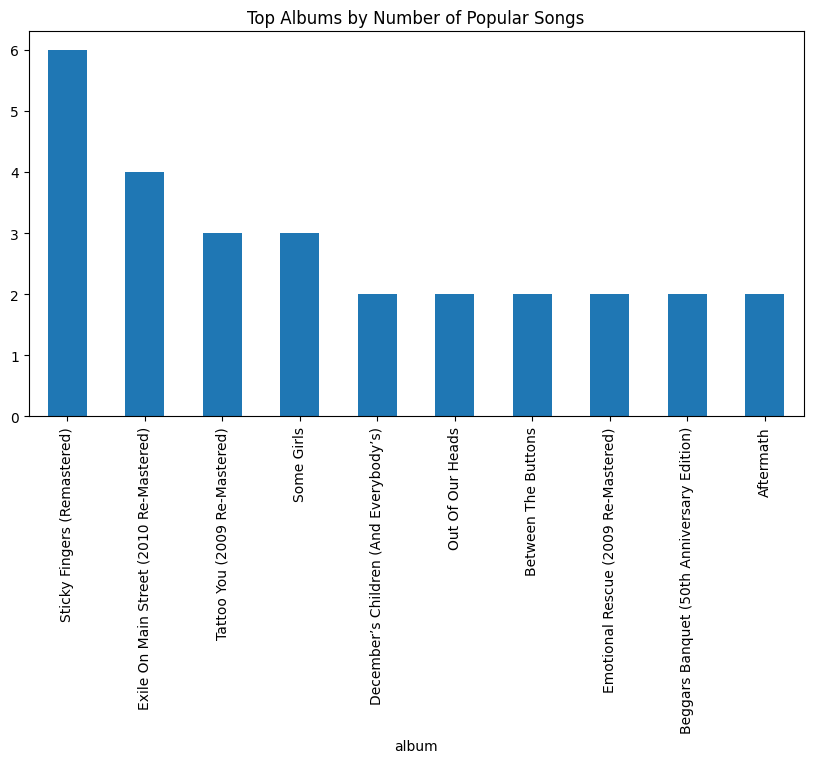

In [6]:
# Exploratory Data Analysis (EDA)

# Find Top Albums (Based on Popular Songs)
popular_albums = df.groupby('album')['is_popular'].sum().sort_values(ascending=False)

popular_albums.head(10)

plt.figure(figsize=(10,5))
popular_albums.head(10).plot(kind='bar')
plt.title("Top Albums by Number of Popular Songs")
plt.show()

# So, Two most popular albums are "Sticky Fingers" and "Exile on Main St." with 4 popular songs each.



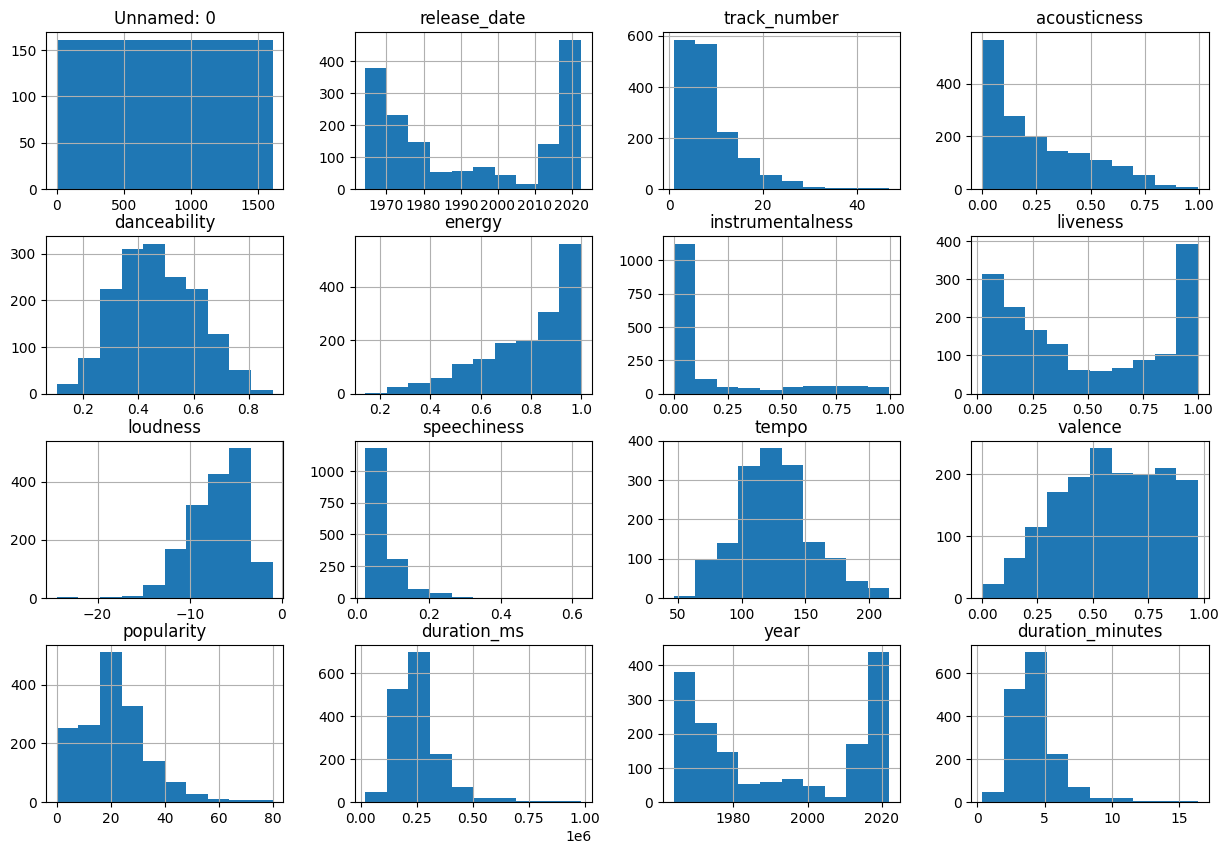

In [8]:
# Feature Engineering
df.hist(figsize=(15,10))
plt.show()

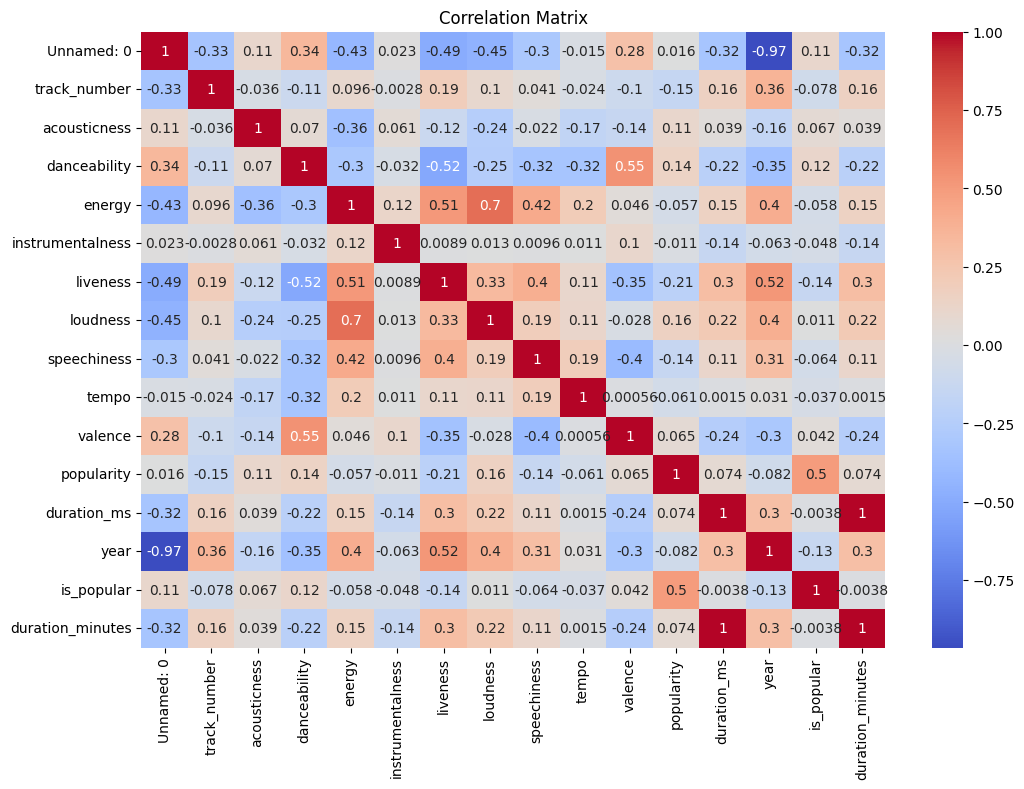

In [7]:
# Correaltion Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

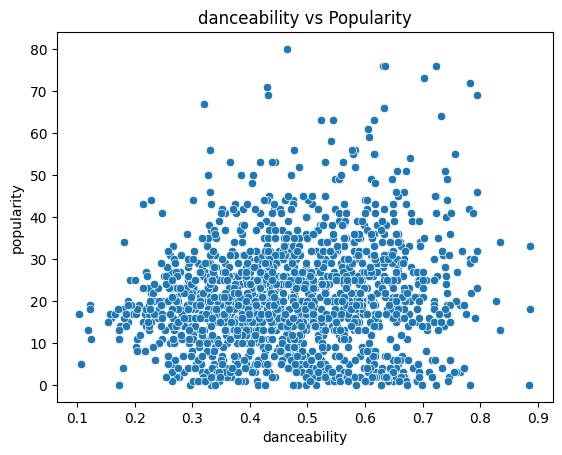

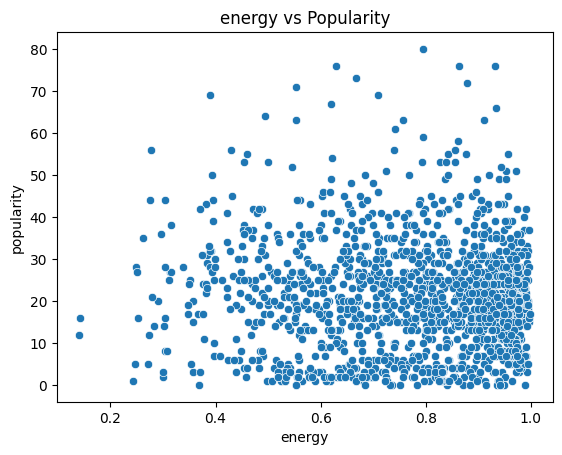

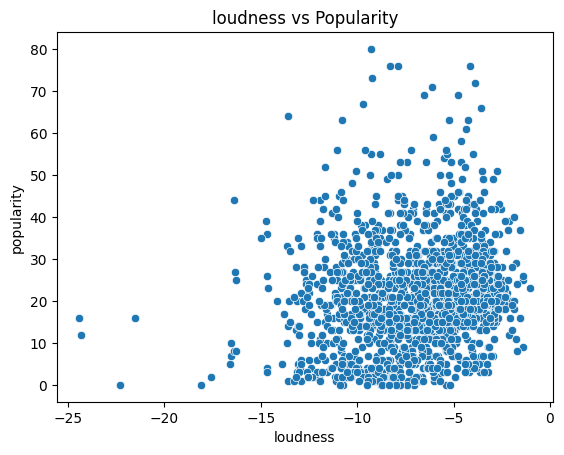

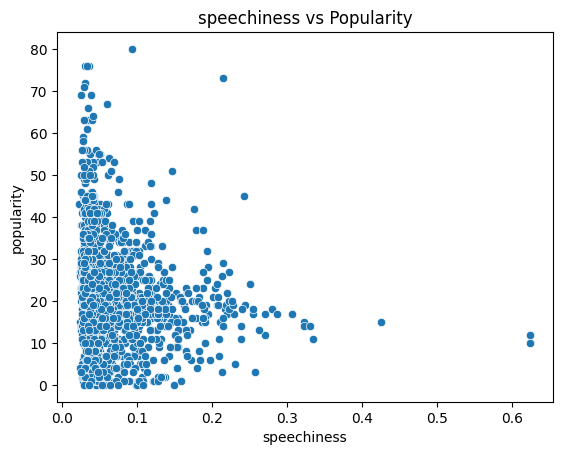

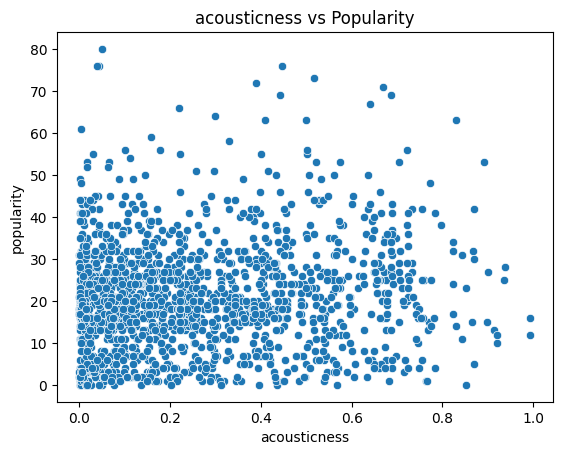

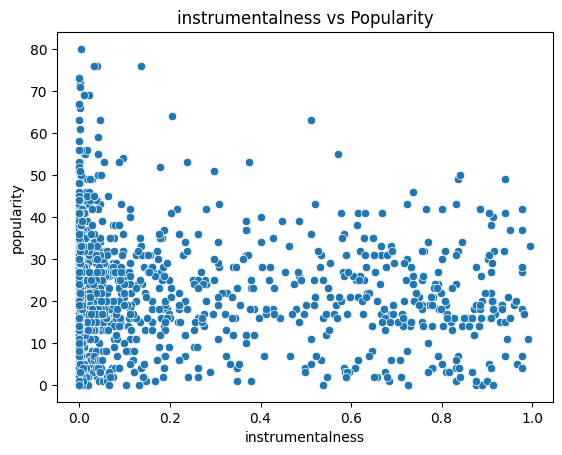

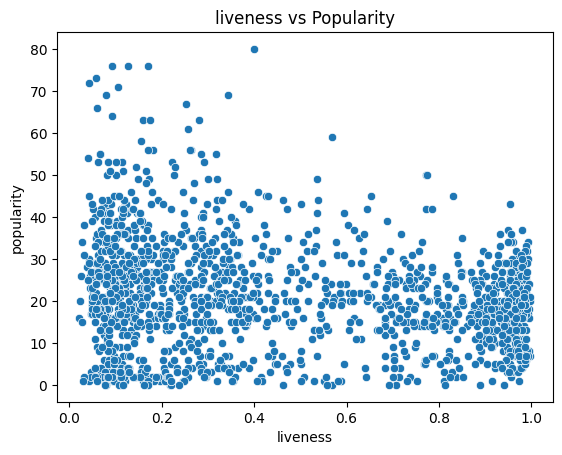

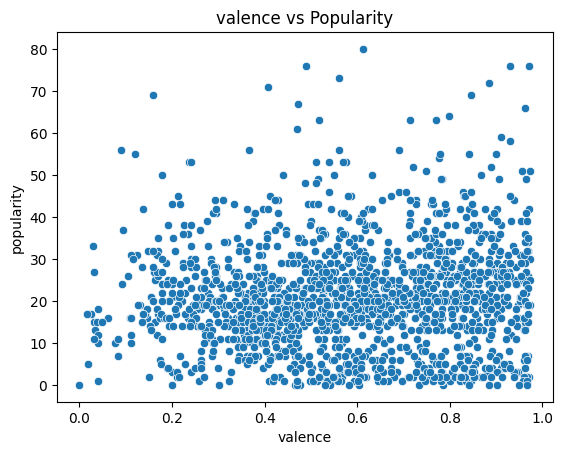

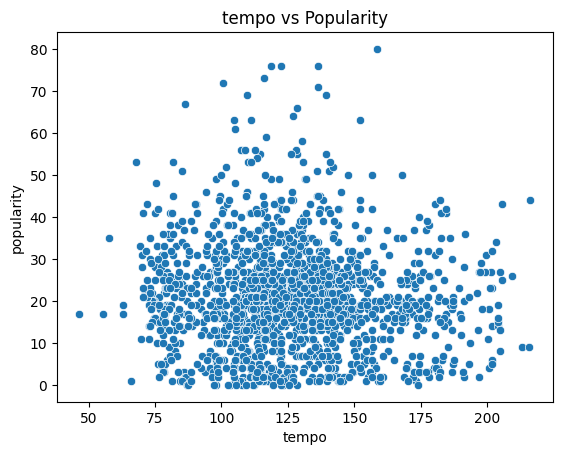

In [8]:
# Popularity vs Features
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
for col in features:
    plt.figure()
    sns.scatterplot(x=df[col], y=df['popularity'])
    plt.title(f"{col} vs Popularity")
    plt.show()

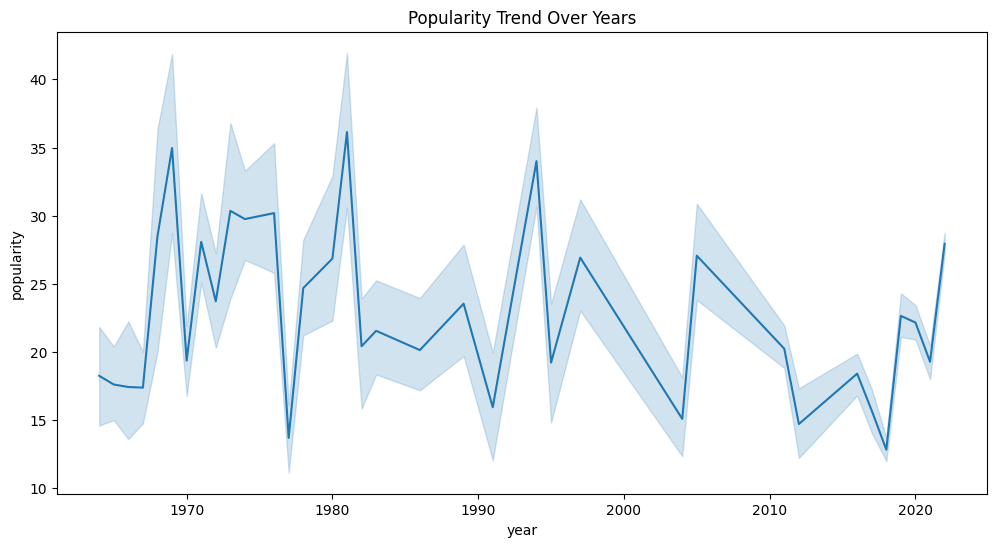

In [9]:
# TREND ANALYSIS
plt.figure(figsize=(12,6))
sns.lineplot(x='year', y='popularity', data=df)
plt.title("Popularity Trend Over Years")
plt.show()

# Dimensionality Reduction (PCA)

# Why PCA?
    Reduces feature complexity
    Removes multicollinearity
    Helps visualize clusters
    Improves clustering performance

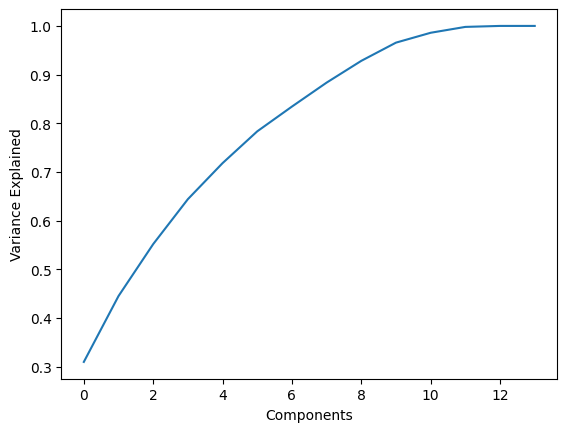

Number of components to explain 90% variance: 9


In [10]:
# Apply Scaling
features = df.select_dtypes(include=np.number).drop(columns=['popularity'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)


# Apply PCA for Dimensionality Reduction
pca = PCA()
pca_data = pca.fit_transform(scaled_data)


# Variance Explained by Each Principal Component
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Variance Explained")
plt.show()


# Choose number of components that explain 90% variance
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.9) + 1
print(f"Number of components to explain 90% variance: {n_components}")
pca = PCA(n_components=n_components)
pca_data = pca.fit_transform(scaled_data)


c:\Users\apoor\miniconda3\envs\data\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
invalid literal for int() with base 10: ''
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\apoor\miniconda3\envs\data\Lib\site-packages\joblib\externals\loky\backend\context.py", line 268, in _count_physical_cores
    cpu_count_physical = sum(map(int, cpu_info))
                         ^^^^^^^^^^^^^^^^^^^^^^^


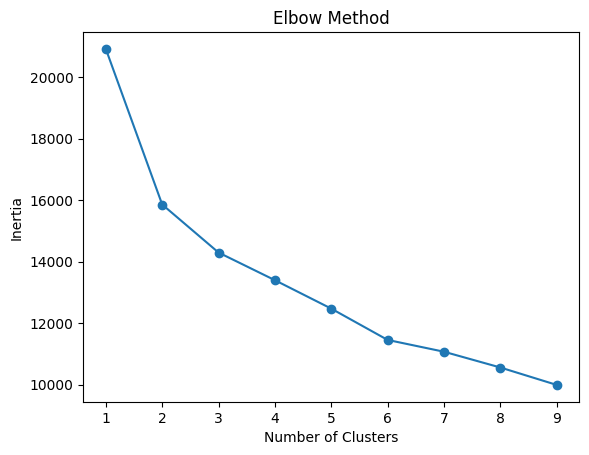

In [11]:
# Clustering with KMeans
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [12]:
# Silhouette Score
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    print(f"k={k}, score={score}")

k=2, score=0.2282524081807012
k=3, score=0.15474019325307664
k=4, score=0.1385213348526858
k=5, score=0.13896981781570042
k=6, score=0.15029864219622813
k=7, score=0.13947347009376354
k=8, score=0.1442226298806845
k=9, score=0.14828900949160712


In [13]:
# Final Model and Cluster Analysis
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(pca_data)

cluster_summary = df.groupby('cluster').mean(numeric_only=True)
cluster_summary

,Unnamed: 0,track_number,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,duration_ms,year,is_popular,duration_minutes
cluster,,,,,,,,,,,,,,,,
0,401.116022,11.408840,0.220574,0.343331,0.930845,0.153810,0.879008,-5.279677,0.125829,137.555884,0.385511,18.022099,351129.444751,2012.290055,0.000000,5.852157
1,1215.794266,6.379427,0.228616,0.547310,0.768079,0.213140,0.298470,-7.755555,0.051128,125.467644,0.736938,21.608769,210382.318718,1971.219224,0.042159,3.506372
2,446.437352,9.969267,0.157250,0.464395,0.861872,0.135081,0.548763,-5.529416,0.060010,124.116073,0.631712,20.810875,237729.186761,2009.853428,0.004728,3.962153
3,1035.482759,7.491379,0.522978,0.472345,0.511543,0.108202,0.277433,-10.237371,0.045954,113.333754,0.403073,22.965517,269528.991379,1979.142241,0.047414,4.492150


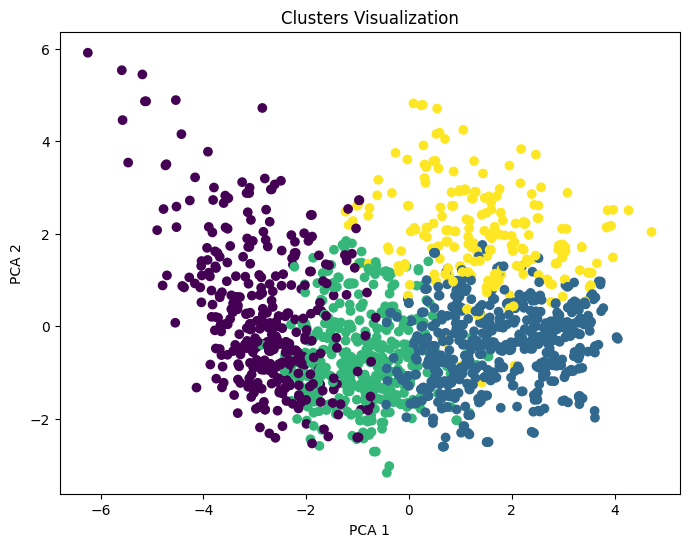

In [14]:
# Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=df['cluster'], cmap='viridis')
plt.title("Clusters Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# Cluster Interpretation

- Cluster 0 → High energy, high loudness → Rock/party songs
- Cluster 1 → High acousticness → Soft acoustic songs
- Cluster 2 → High danceability + high valence → Happy dance songs
- Cluster 3 → Low energy + low valence → Sad/slow songs

These cluster labels are inferred from the feature patterns observed in each cohort. The final cluster visualization above supports this interpretation by showing how different songs group based on these traits.



# Key Findings:
- Top albums based on popularity: Sticky Fingers & Exile on Main St.
- Popular songs tend to have:
  - Higher energy
  - Higher danceability
- PCA helped reduce features from ~12 → 5
- Clustering grouped songs into meaningful categories

The charts above illustrate album recommendations, song feature relationships, PCA dimensionality reduction, and the final song clusters.
